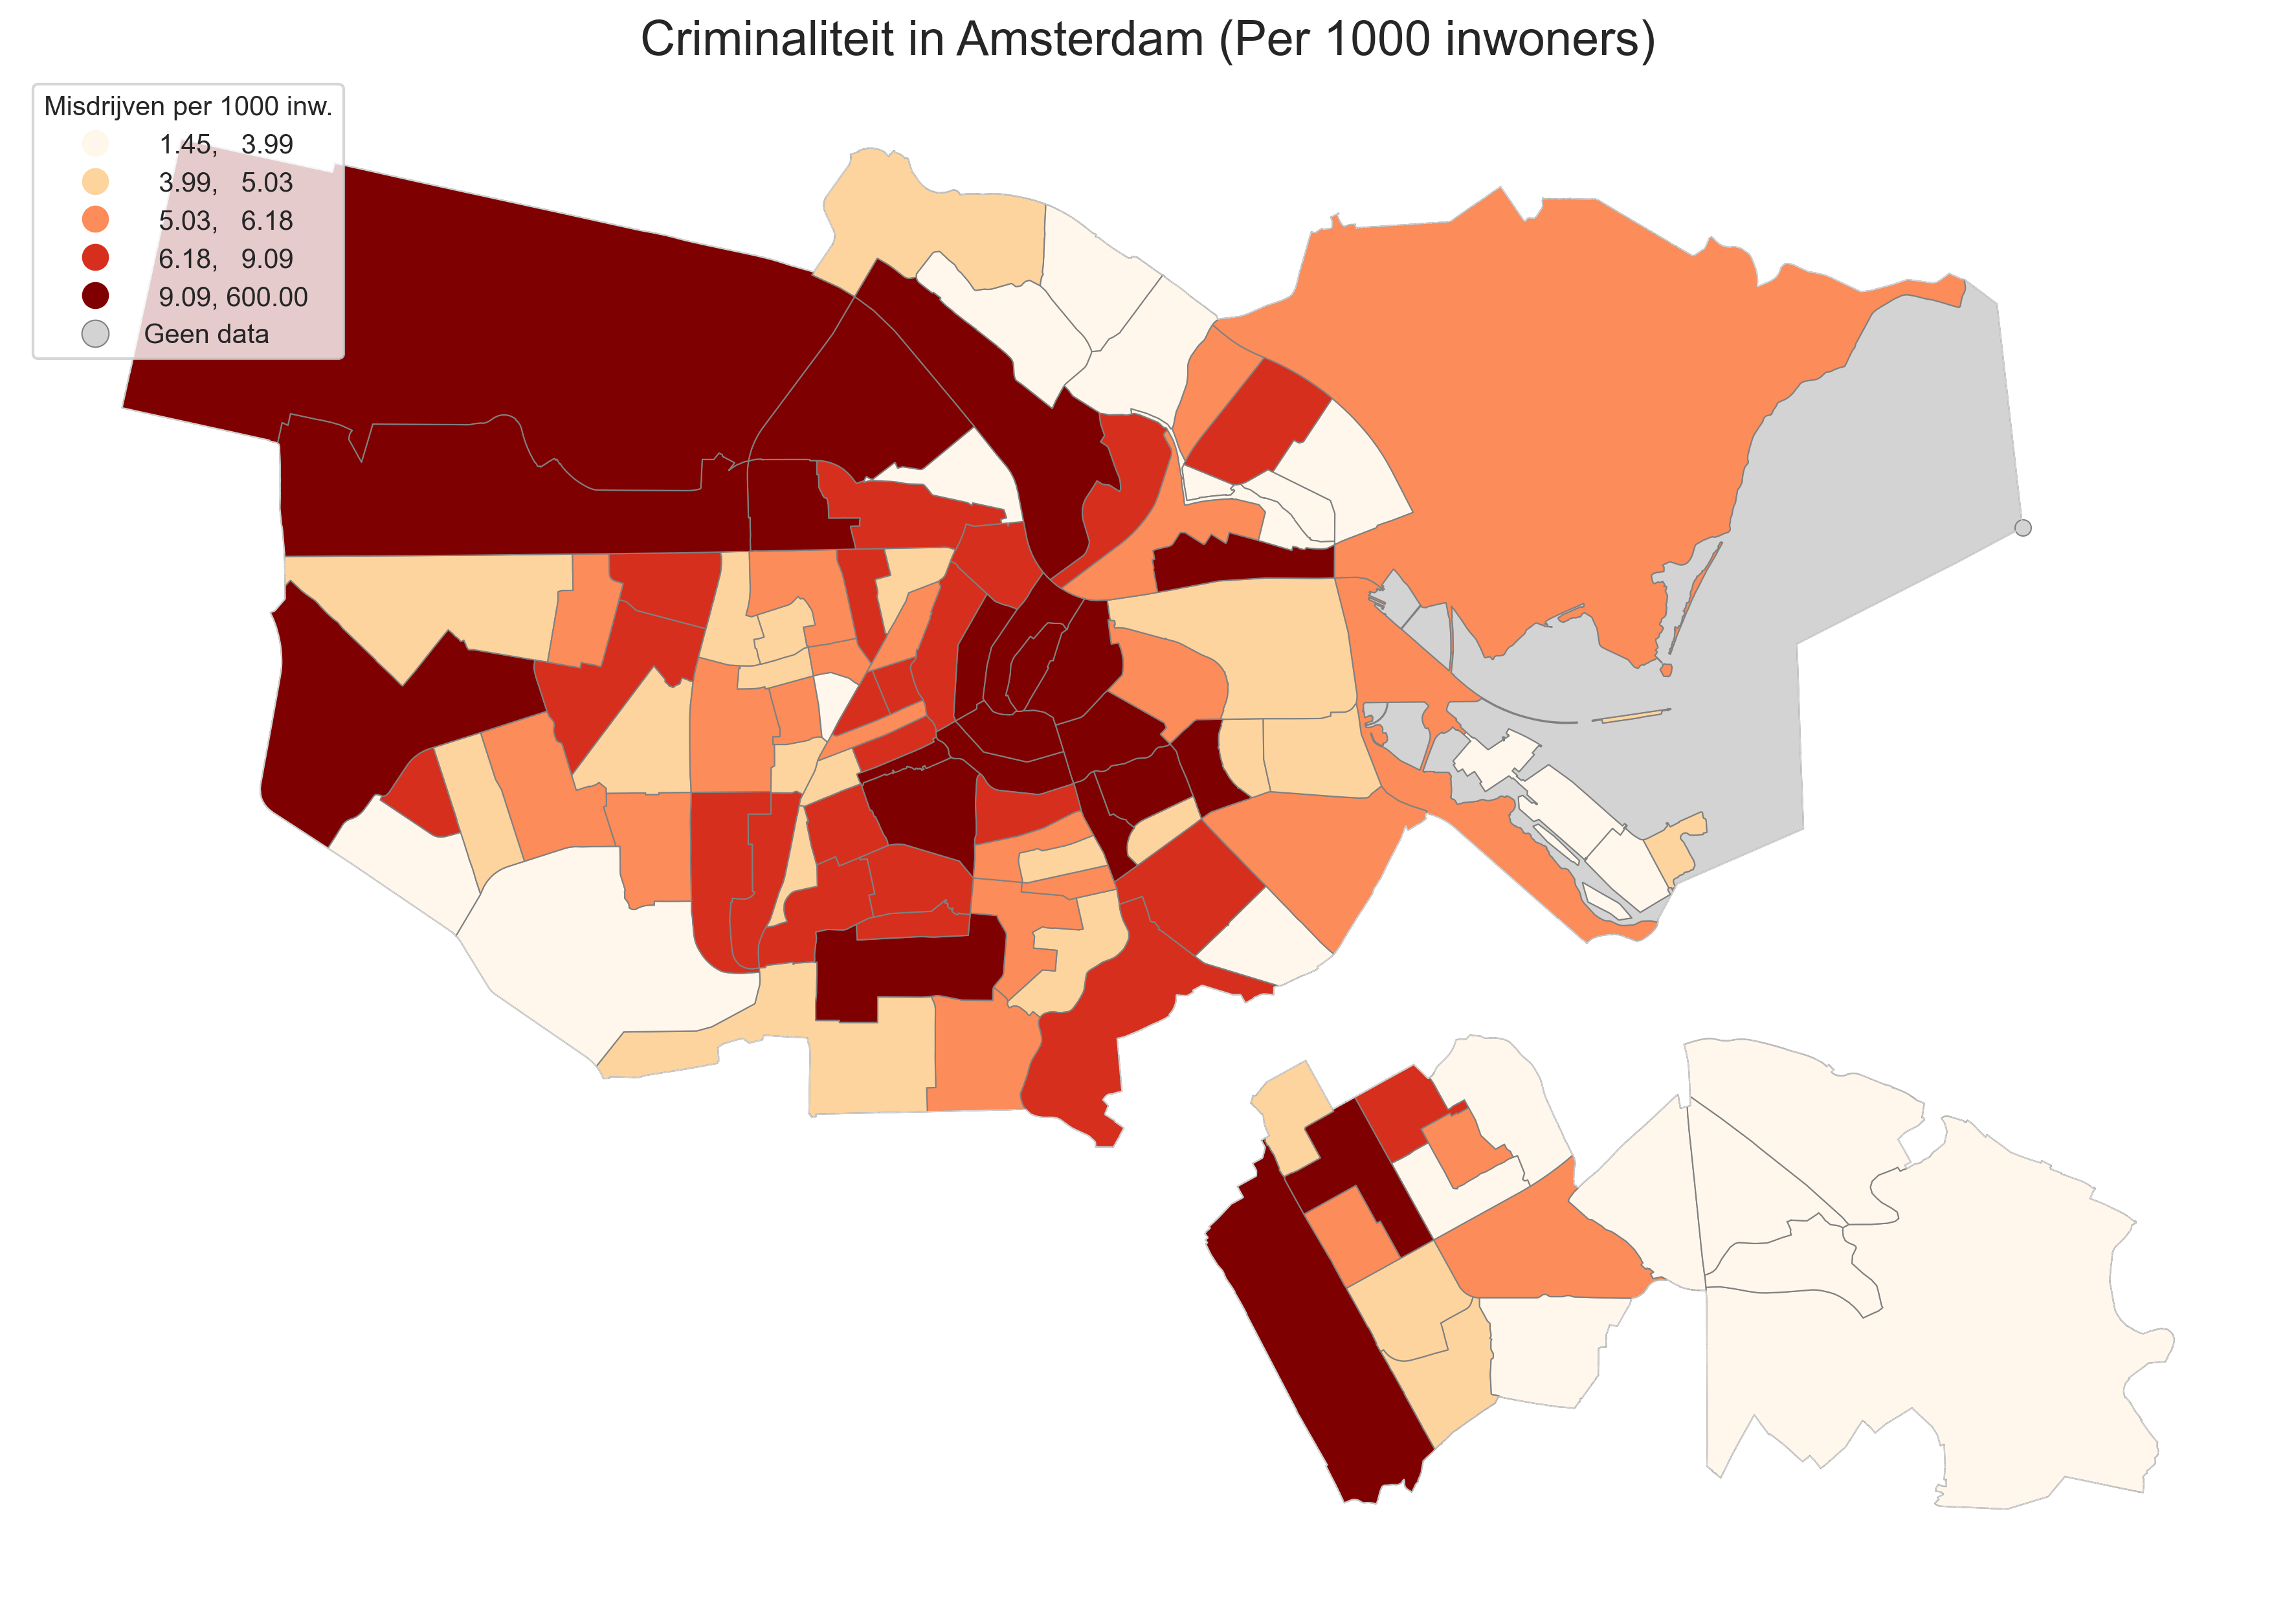

In [7]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. LAAD DE KAART (GEOMETRIE)
# Geopackage data
gemeenten = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer="gemeenten")
amsterdam_grens = gemeenten[gemeenten['gemeentenaam'] == 'Amsterdam']

wijken = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer="wijken")
amsterdam_wijken = gpd.clip(wijken, amsterdam_grens)

# 2. LAAD JE NIEUWE DATA
total = pd.read_csv("data/total_final_df.csv")

# 3. KOPPELEN
amsterdam_data = amsterdam_wijken.merge(
    total,
    left_on='wijknaam',
    right_on='wijknaam',
    how='left'
)

# 4. PLOTTEN
fig, ax = plt.subplots(figsize=(15, 12), dpi=300)

amsterdam_data.plot(
    column='Misdrijven_per_1000_inwoners',
    scheme='quantiles',
    k=5,
    cmap='OrRd',
    linewidth=0.5,
    edgecolor='grey',
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': "Misdrijven per 1000 inw."},
    missing_kwds={'color': 'lightgrey', 'label': 'Geen data'},
    ax=ax
)

ax.set_title("Criminaliteit in Amsterdam (Per 1000 inwoners)", fontsize=18)
ax.set_axis_off()

plt.show()